In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import torch.optim as optim

In [2]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # ENCODER
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2) ,

            nn.Conv2d(in_channels=8, out_channels=4, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # DECODER
        self.decoder = nn.Sequential(
            nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'),

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'),
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'),
            
            nn.Conv2d(in_channels=64, out_channels=1, kernel_size=3, padding=1),
            nn.Upsample(scale_factor=2, mode='nearest'), 
            nn.Sigmoid() 
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequentia

In [4]:
IMG_HEIGHT = 512
IMG_WIDTH = 512
batch_size = 8

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder('casting_512x512/casting_512x512/', transform=transform)

ok_class_idx = dataset.class_to_idx['ok_front']
def_class_idx = dataset.class_to_idx['def_front']

ok_indices = [i for i, (_, label) in enumerate(dataset) if label == ok_class_idx]
def_indices = [i for i, (_, label) in enumerate(dataset) if label == def_class_idx]

train_idx, val_idx = train_test_split(ok_indices, test_size=0.2, random_state=42)

train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size, shuffle=False)
anomaly_loader = DataLoader(Subset(dataset, def_indices), batch_size=batch_size, shuffle=False)


In [5]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 5

for epoch in range(epochs):
    model.train() 
    train_loss = 0.0
    
    for images, _ in train_loader:
        images = images.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, images)
        
        optimizer.zero_grad() 
        loss.backward()       
        optimizer.step()     
        
        train_loss += loss.item() * images.size(0)
        
    train_loss = train_loss / len(train_loader.dataset)
    
    model.eval() 
    val_loss = 0.0
    
    with torch.no_grad(): 
        for images, _ in val_loader:
            images = images.to(device)

            outputs = model(images)
            loss = criterion(outputs, images)
            
            val_loss += loss.item() * images.size(0)
            
    val_loss = val_loss / len(val_loader.dataset)
    
    print(f"Epoch [{epoch+1}/{epochs}] - loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

Epoch [1/5] - loss: 0.0516 - val_loss: 0.0236
Epoch [2/5] - loss: 0.0160 - val_loss: 0.0129
Epoch [3/5] - loss: 0.0108 - val_loss: 0.0102
Epoch [4/5] - loss: 0.0089 - val_loss: 0.0087
Epoch [5/5] - loss: 0.0081 - val_loss: 0.0082


Reconstruction Quality Analysis


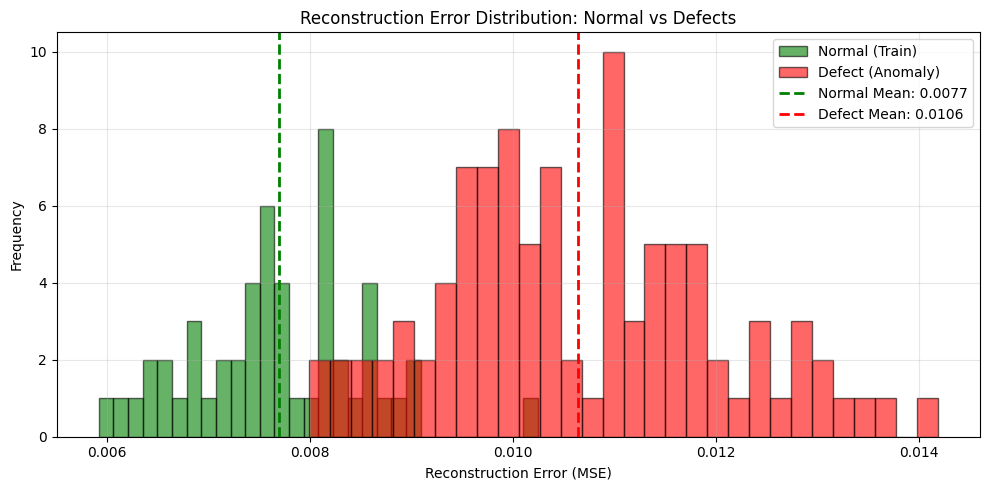

Normal Recon Error - Mean: 0.007701, Std: 0.000842
Defect Recon Error - Mean: 0.010639, Std: 0.001358
Separation Gap: 0.002938


In [6]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("Reconstruction Quality Analysis")
print("=" * 60)

train_recon_errors = []
with torch.no_grad():
    for images, _ in train_loader:
        images = images.to(device)
        reconstructions = model(images)
        mse = nn.MSELoss()(reconstructions, images)
        train_recon_errors.append(mse.item())

train_recon_errors = np.array(train_recon_errors)

defect_recon_errors = []
with torch.no_grad():
    for images, _ in anomaly_loader:
        images = images.to(device)
        reconstructions = model(images)
        mse = nn.MSELoss()(reconstructions, images)
        defect_recon_errors.append(mse.item())

defect_recon_errors = np.array(defect_recon_errors)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_recon_errors, bins=30, alpha=0.6, label='Normal (Train)', color='green', edgecolor='black')
ax.hist(defect_recon_errors, bins=30, alpha=0.6, label='Defect (Anomaly)', color='red', edgecolor='black')
ax.axvline(train_recon_errors.mean(), color='green', linestyle='--', linewidth=2, label=f'Normal Mean: {train_recon_errors.mean():.4f}')
ax.axvline(defect_recon_errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Defect Mean: {defect_recon_errors.mean():.4f}')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Frequency')
ax.set_title('Reconstruction Error Distribution: Normal vs Defects')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Normal Recon Error - Mean: {train_recon_errors.mean():.6f}, Std: {train_recon_errors.std():.6f}")
print(f"Defect Recon Error - Mean: {defect_recon_errors.mean():.6f}, Std: {defect_recon_errors.std():.6f}")
print(f"Separation Gap: {defect_recon_errors.mean() - train_recon_errors.mean():.6f}")
print("=" * 60)

In [7]:
from sklearn.neighbors import KernelDensity
import numpy as np

model.eval()

encoded_train_images = []

print("Extracting features for KDE...")
with torch.no_grad():
    for images, _ in train_loader:
        images = images.to(device)
        
        latent = model.encoder(images)
        
        latent_flat = latent.view(latent.size(0), -1).cpu().numpy()
        encoded_train_images.append(latent_flat)

encoded_train_images = np.concatenate(encoded_train_images, axis=0)

print("Fitting KDE...")
kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(encoded_train_images)
print("KDE Fit Complete!")

Extracting features for KDE...
Fitting KDE...
KDE Fit Complete!


Extracting latent features for anomalies...
Reducing dimensionality with PCA...
Reducing dimensionality with t-SNE (this may take a minute)...


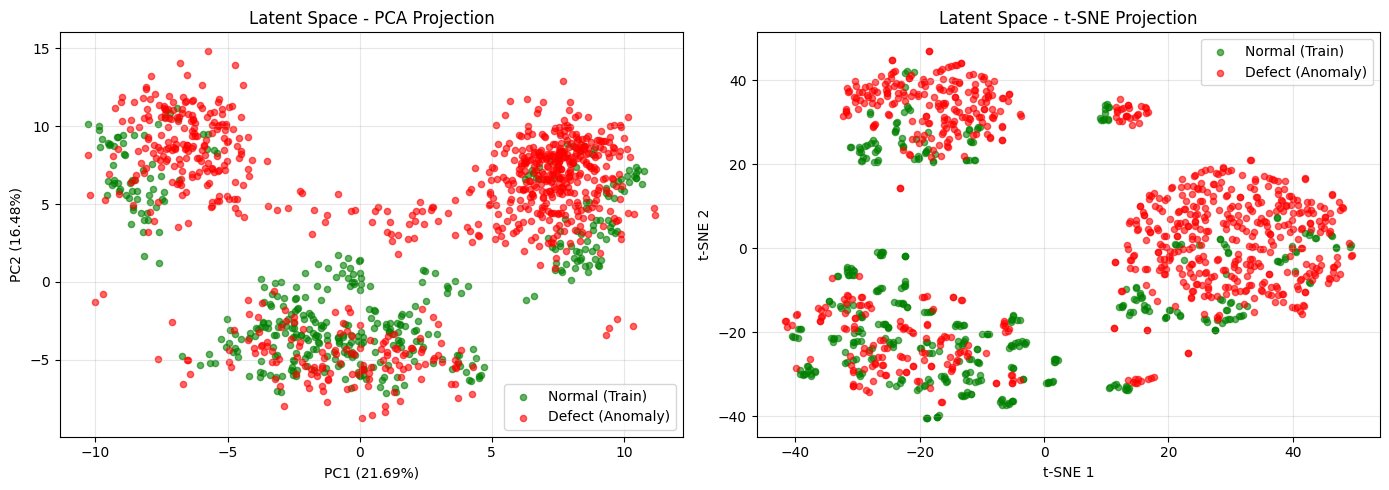

Normal images in latent space: 415
Defect images in latent space: 781
Latent space dimension: 1024


In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Extracting latent features for anomalies...")
encoded_anomaly_images = []
with torch.no_grad():
    for images, _ in anomaly_loader:
        images = images.to(device)
        latent = model.encoder(images)
        latent_flat = latent.view(latent.size(0), -1).cpu().numpy()
        encoded_anomaly_images.append(latent_flat)

encoded_anomaly_images = np.concatenate(encoded_anomaly_images, axis=0)

print("Reducing dimensionality with PCA...")
pca = PCA(n_components=2)
train_latent_pca = pca.fit_transform(encoded_train_images)
anomaly_latent_pca = pca.transform(encoded_anomaly_images)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train_latent_pca[:, 0], train_latent_pca[:, 1], c='green', label='Normal (Train)', alpha=0.6, s=20)
axes[0].scatter(anomaly_latent_pca[:, 0], anomaly_latent_pca[:, 1], c='red', label='Defect (Anomaly)', alpha=0.6, s=20)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
axes[0].set_title('Latent Space - PCA Projection')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

print("Reducing dimensionality with t-SNE (this may take a minute)...")
combined_latent = np.vstack([encoded_train_images, encoded_anomaly_images])
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
combined_latent_tsne = tsne.fit_transform(combined_latent)

train_latent_tsne = combined_latent_tsne[:len(encoded_train_images)]
anomaly_latent_tsne = combined_latent_tsne[len(encoded_train_images):]

axes[1].scatter(train_latent_tsne[:, 0], train_latent_tsne[:, 1], c='green', label='Normal (Train)', alpha=0.6, s=20)
axes[1].scatter(anomaly_latent_tsne[:, 0], anomaly_latent_tsne[:, 1], c='red', label='Defect (Anomaly)', alpha=0.6, s=20)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('Latent Space - t-SNE Projection')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Normal images in latent space: {len(encoded_train_images)}")
print(f"Defect images in latent space: {len(encoded_anomaly_images)}")
print(f"Latent space dimension: {encoded_train_images.shape[1]}")


In [9]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn as nn

def check_anomaly(img_path, density_threshold, recon_error_threshold):
    img = Image.open(img_path).convert('L')
    
    transform = transforms.Compose([
        transforms.ToTensor() 
    ])
    
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        reconstruction = model(img_tensor)
        reconstruction_error = nn.MSELoss()(reconstruction, img_tensor).item()
        
        latent = model.encoder(img_tensor)
        latent_flat = latent.view(latent.size(0), -1).cpu().numpy()
        density = kde.score_samples(latent_flat)[0]
    
    plt.imshow(img, cmap='gray')
    plt.title(f"Density: {density:.2f} | Recon Error: {reconstruction_error:.4f}")
    plt.axis('off')
    plt.show()

    if density < density_threshold or reconstruction_error > recon_error_threshold:
        print("RESULT: The image is an ANOMALY ❌")
    else:
        print("RESULT: The image is NORMAL/GOOD ✅")

Testing an Anomaly Image:


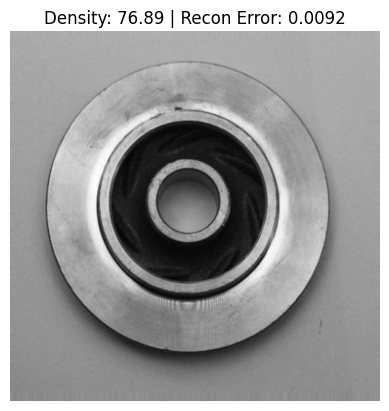

RESULT: The image is an ANOMALY ❌

Testing a Normal Image:


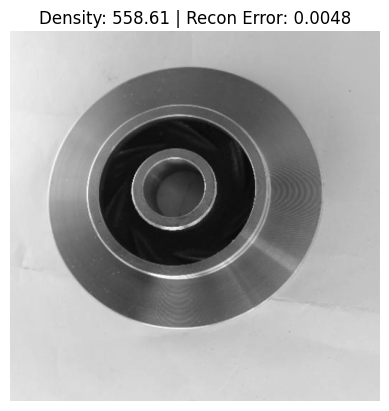

RESULT: The image is an ANOMALY ❌


In [12]:
import random
import glob

anomaly_paths = glob.glob('casting_512x512/casting_512x512/def_front/*')
normal_paths = glob.glob('casting_512x512/casting_512x512/ok_front/*')

DENSITY_THRESH = 300 #naj 2700
RECON_THRESH = 0.0029 #naj 0.005

print("Testing an Anomaly Image:")
test_img = random.choice(anomaly_paths)
check_anomaly(test_img, density_threshold=DENSITY_THRESH, recon_error_threshold=RECON_THRESH)

print("\nTesting a Normal Image:")
test_img = random.choice(normal_paths)
check_anomaly(test_img, density_threshold=DENSITY_THRESH, recon_error_threshold=RECON_THRESH)